# **DAV R Project**

## **Student name: Merna Amr**

**GEO Accession Data used:** GSE112680

**Summary of used data:** 	Transcriptome-wide analysis of whole blood gene expression profiles of ALS patients, gender- and age-matched controls and patients diagnosed with diseases mimicking ALS at a tertiary referral center for motor neuron diseases.

Open Drive (Using Python then switch runtime to R)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Load Required Libraries

In [ ]:
# Load all libraries from the source
.libPaths(c("/content/drive/MyDrive/Colab Notebooks/R_lib", .libPaths()))
library(limma)
library(ggplot2)
library(patchwork)

Check the imported data and its structure

In [ ]:
#Read Expression Data
df=read.table("/content/drive/MyDrive/Colab Notebooks/davrproject/GSE112680_HT12_V4_preQC_nonnormalized.txt",sep="\t", header=TRUE, check.names=FALSE, stringsAsFactors=FALSE, row.names = 1)

#Check its content
head(df, n=5)
tail(df, n=5)
dim(df)
mode(df)
sum(sapply(df, is.numeric))
is.numeric(df)
is.character(df)

,ALS03718.AVG_Signal,ALS03718.Detection_Pval,ALS03729.AVG_Signal,ALS03729.Detection_Pval,ALS05873.AVG_Signal,ALS05873.Detection_Pval,ALS07130.AVG_Signal,ALS07130.Detection_Pval,ALS04157.AVG_Signal,ALS04157.Detection_Pval,⋯,ALS04978.AVG_Signal,ALS04978.Detection_Pval,ALS05161.AVG_Signal,ALS05161.Detection_Pval,ALS06059.AVG_Signal,ALS06059.Detection_Pval,ALS04688.AVG_Signal,ALS04688.Detection_Pval,ALS06998.AVG_Signal,ALS06998.Detection_Pval
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ILMN_1762337,102.52300,0.1688312,89.84062,0.59350650,87.62189,0.80000000,86.53268,0.37532470,96.08231,0.12467530,⋯,104.84600,0.5948052,140.6617,0.28441560,123.0168,0.45194800,119.5586,0.49220780,141.8504,0.21428570
ILMN_2055271,102.44780,0.1714286,98.84846,0.06883117,99.90469,0.08051948,88.92479,0.19350650,99.08932,0.04545455,⋯,110.33300,0.4233766,155.3012,0.08441558,161.1041,0.01168831,123.4620,0.40129870,155.0951,0.06883117
ILMN_1736007,97.20568,0.4597403,87.37596,0.78051950,92.54353,0.44155850,92.77156,0.04935065,91.63874,0.36883120,⋯,97.76569,0.7831169,121.4493,0.69870130,124.9471,0.39350650,123.4988,0.40000000,138.6829,0.25064940
ILMN_2383229,99.08691,0.3428572,90.47139,0.54545460,86.40297,0.85324670,89.43089,0.17272730,93.42685,0.25714290,⋯,109.72820,0.4480520,141.8024,0.24675320,141.7934,0.10779220,136.0494,0.13506490,152.9964,0.08961039
ILMN_1806310,99.31527,0.3259740,92.85598,0.37662340,99.32949,0.09480520,89.51527,0.16883120,91.73763,0.35714290,⋯,122.80080,0.1272727,138.6053,0.31948050,130.3917,0.26883120,145.6392,0.04155844,138.2055,0.26103900


,ALS03718.AVG_Signal,ALS03718.Detection_Pval,ALS03729.AVG_Signal,ALS03729.Detection_Pval,ALS05873.AVG_Signal,ALS05873.Detection_Pval,ALS07130.AVG_Signal,ALS07130.Detection_Pval,ALS04157.AVG_Signal,ALS04157.Detection_Pval,⋯,ALS04978.AVG_Signal,ALS04978.Detection_Pval,ALS05161.AVG_Signal,ALS05161.Detection_Pval,ALS06059.AVG_Signal,ALS06059.Detection_Pval,ALS04688.AVG_Signal,ALS04688.Detection_Pval,ALS06998.AVG_Signal,ALS06998.Detection_Pval
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ILMN_2371169,813.5322,0.000000000,896.3784,0.00000000,712.40250,0.00000000,509.11450,0.0000000,1047.20900,0.00000000,⋯,1601.9030,0.0000000,2475.2480,0.000000000,2671.6640,0.000000000,2007.7000,0.00000000,2620.7890,0.00000000
ILMN_1701875,2008.6780,0.000000000,1792.6860,0.00000000,1568.26200,0.00000000,590.34550,0.0000000,1332.07700,0.00000000,⋯,2331.0760,0.0000000,4862.7510,0.000000000,4701.9390,0.000000000,3316.2510,0.00000000,4337.3530,0.00000000
ILMN_1786396,240.3134,0.000000000,215.1228,0.00000000,189.23460,0.00000000,123.78440,0.0000000,171.37900,0.00000000,⋯,303.6599,0.0000000,429.1169,0.000000000,480.9661,0.000000000,356.7259,0.00000000,454.3553,0.00000000
ILMN_1653618,133.1772,0.003896104,103.8422,0.01818182,104.76330,0.01818182,89.67361,0.1623377,97.43087,0.08181818,⋯,117.7986,0.2311688,206.8793,0.001298701,178.9162,0.002597403,148.2725,0.03376623,175.4671,0.01168831
ILMN_2137536,103.4367,0.136363600,104.2644,0.01298701,94.55844,0.29610390,88.96255,0.1935065,91.46342,0.38571430,⋯,116.7879,0.2597403,165.1671,0.022077920,164.8235,0.007792208,127.9721,0.28051950,169.5348,0.01948052


[1] 47323   752

[1] "list"

[1] 752

[1] FALSE

[1] FALSE

Modify/Fix data

In [ ]:
# Separate expression and detection columns
expr_cols= grep("AVG_Signal", colnames(df))
det_cols = grep("Detection_Pval", colnames(df))

expr_raw = df[, expr_cols]
det_raw = df[, det_cols]

# Convert to numeric
expr_raw = matrix(as.numeric(gsub(",", "", as.matrix(expr_raw))),
                   nrow=nrow(expr_raw),
                   dimnames=dimnames(expr_raw))

det_raw = matrix(as.numeric(as.matrix(det_raw)),
                   nrow=nrow(det_raw),
                   dimnames=dimnames(det_raw))


Check after modification

In [ ]:
head(expr_cols, n=5)
head(expr_raw,n=5)
mode(expr_raw)
class(expr_raw)
dim(expr_raw)
is.numeric(expr_raw)
sum(sapply(expr_raw, is.numeric))


head(det_cols,n=5)
head(det_raw,n=5)
mode(det_raw)
class(det_raw)
dim(det_raw)
is.numeric(det_raw)
sum(sapply(det_raw, is.numeric))


[1] 1 3 5 7 9

,ALS03718.AVG_Signal,ALS03729.AVG_Signal,ALS05873.AVG_Signal,ALS07130.AVG_Signal,ALS04157.AVG_Signal,ALS03901.AVG_Signal,ALS05882.AVG_Signal,ALS04332.AVG_Signal,ALS04139.AVG_Signal,ALS05942.AVG_Signal,⋯,ALS06060.AVG_Signal,ALS06168.AVG_Signal,ALS04910.AVG_Signal,ALS06170.AVG_Signal,ALS06166.AVG_Signal,ALS04978.AVG_Signal,ALS05161.AVG_Signal,ALS06059.AVG_Signal,ALS04688.AVG_Signal,ALS06998.AVG_Signal
ILMN_1762337,102.52300,89.84062,87.62189,86.53268,96.08231,90.80424,92.07882,91.97278,83.52052,97.87142,⋯,126.0325,108.5462,101.90760,115.4965,120.6358,104.84600,140.6617,123.0168,119.5586,141.8504
ILMN_2055271,102.44780,98.84846,99.90469,88.92479,99.08932,100.76290,95.09328,97.12000,97.05634,117.72910,⋯,123.7426,106.2982,99.78574,101.9040,124.1361,110.33300,155.3012,161.1041,123.4620,155.0951
ILMN_1736007,97.20568,87.37596,92.54353,92.77156,91.63874,90.59134,92.03480,93.06264,90.41402,99.14166,⋯,108.5026,106.8435,117.08460,101.2074,118.8114,97.76569,121.4493,124.9471,123.4988,138.6829
ILMN_2383229,99.08691,90.47139,86.40297,89.43089,93.42685,94.88033,87.80912,88.59678,95.04036,105.89400,⋯,110.8435,115.2369,117.57090,112.4942,138.1431,109.72820,141.8024,141.7934,136.0494,152.9964
ILMN_1806310,99.31527,92.85598,99.32949,89.51527,91.73763,91.91100,99.32870,88.91814,96.68195,104.25890,⋯,124.8098,100.5850,102.62730,117.9463,118.2580,122.80080,138.6053,130.3917,145.6392,138.2055


[1] "numeric"

[1] "matrix" "array"

[1] 47323   376

...

[1] "numeric"

[1] "matrix" "array"

[1] 47323   376

[1] TRUE

[1] 17793448

Detection P-value filtering

In [ ]:
# Detection P-value Filtering
# Keep genes detected (p < 0.01) in >= 20% of samples

detected = rowMeans(det_raw < 0.01, na.rm=TRUE)

expr_filtered= expr_raw[detected >= 0.20, ]

cat("Genes after detection filtering:", nrow(expr_filtered))


Genes after detection filtering: 14406

Missing vaules

In [ ]:
#Detecting missing values
sum(is.na(expr_filtered))
sum(expr_filtered ==0)

[1] 0

[1] 0

Log2 Transformation

In [ ]:
summary(expr_filtered)

 ALS03718.AVG_Signal ALS03729.AVG_Signal ALS05873.AVG_Signal
 Min.   :   90.36    Min.   :   81.73    Min.   :   84.08   
 1st Qu.:  126.58    1st Qu.:  113.73    1st Qu.:  108.86   
 Median :  166.91    Median :  144.93    Median :  132.10   
 Mean   :  535.14    Mean   :  429.43    Mean   :  386.02   
 3rd Qu.:  310.91    3rd Qu.:  257.61    3rd Qu.:  221.06   
 Max.   :24041.56    Max.   :20312.71    Max.   :20785.39   
 ALS07130.AVG_Signal ALS04157.AVG_Signal ALS03901.AVG_Signal
 Min.   :   73.19    Min.   :   76.06    Min.   :   84.16   
 1st Qu.:   93.45    1st Qu.:  106.22    1st Qu.:  117.70   
 Median :  105.31    Median :  129.36    Median :  152.72   
 Mean   :  242.50    Mean   :  381.09    Mean   :  445.39   
 3rd Qu.:  147.38    3rd Qu.:  220.21    3rd Qu.:  279.69   
 Max.   :19089.72    Max.   :25771.93    Max.   :24290.22   
 ALS05882.AVG_Signal ALS04332.AVG_Signal ALS04139.AVG_Signal
 Min.   :   73.64    Min.   :   82.45    Min.   :   78.93   
 1st Qu.:  101.36    1st

In [ ]:
#Log2 transformation
expr_log = log2(expr_filtered)
#Check
summary(expr_log)


 ALS03718.AVG_Signal ALS03729.AVG_Signal ALS05873.AVG_Signal
 Min.   : 6.498      Min.   : 6.353      Min.   : 6.394     
 1st Qu.: 6.984      1st Qu.: 6.830      1st Qu.: 6.766     
 Median : 7.383      Median : 7.179      Median : 7.046     
 Mean   : 7.885      Mean   : 7.663      Mean   : 7.529     
 3rd Qu.: 8.280      3rd Qu.: 8.009      3rd Qu.: 7.788     
 Max.   :14.553      Max.   :14.310      Max.   :14.343     
 ALS07130.AVG_Signal ALS04157.AVG_Signal ALS03901.AVG_Signal
 Min.   : 6.193      Min.   : 6.249      Min.   : 6.395     
 1st Qu.: 6.546      1st Qu.: 6.731      1st Qu.: 6.879     
 Median : 6.719      Median : 7.015      Median : 7.255     
 Mean   : 7.098      Mean   : 7.500      Mean   : 7.730     
 3rd Qu.: 7.203      3rd Qu.: 7.783      3rd Qu.: 8.128     
 Max.   :14.221      Max.   :14.654      Max.   :14.568     
 ALS05882.AVG_Signal ALS04332.AVG_Signal ALS04139.AVG_Signal
 Min.   : 6.202      Min.   : 6.365      Min.   : 6.303     
 1st Qu.: 6.663      1st

Visualize Data before and after Log2 Transformation using density plot

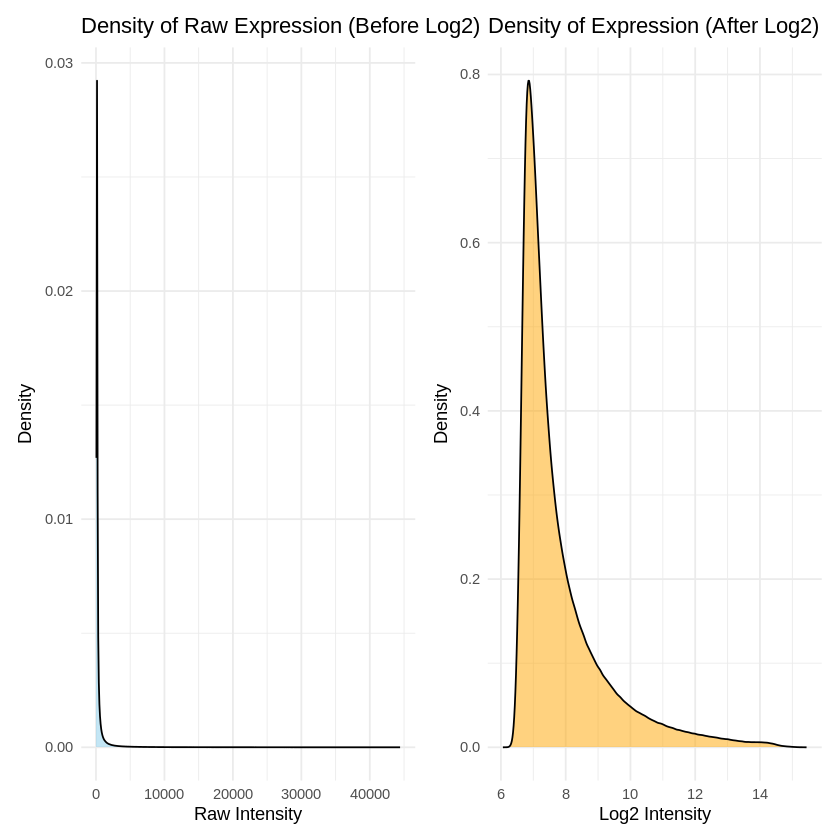

In [ ]:
#visualization before and after

# Convert matrix to vector for density plotting
Before_df = data.frame(Intensity = as.vector(expr_filtered))
After_df = data.frame(Intensity = as.vector(expr_log))

p1 = ggplot(Before_df, aes(x = Intensity)) +
  geom_density(fill = "skyblue", alpha = 0.5) +
  labs(title = "Density of Raw Expression (Before Log2)",
       x = "Raw Intensity",
       y = "Density") +
  theme_minimal()

p2 = ggplot(After_df, aes(x = Intensity)) +
  geom_density(fill = "orange", alpha = 0.5) +
  labs(title = "Density of Expression (After Log2)",
       x = "Log2 Intensity",
       y = "Density") +
  theme_minimal()

p1 + p2

Normalization

In [ ]:
expr_norm= normalizeBetweenArrays(expr_log, method="quantile")

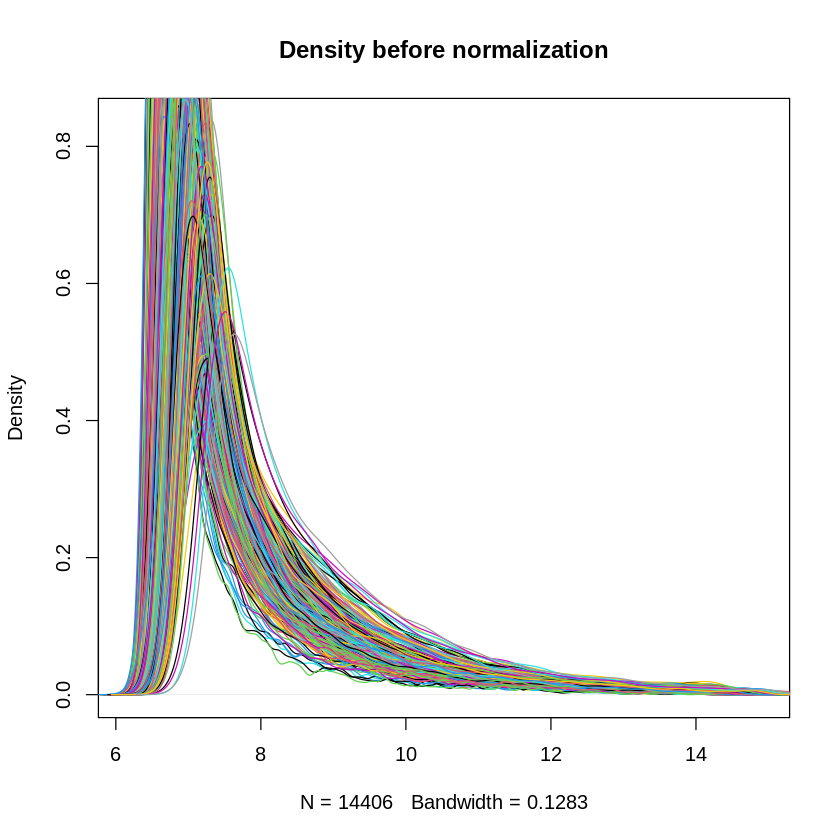

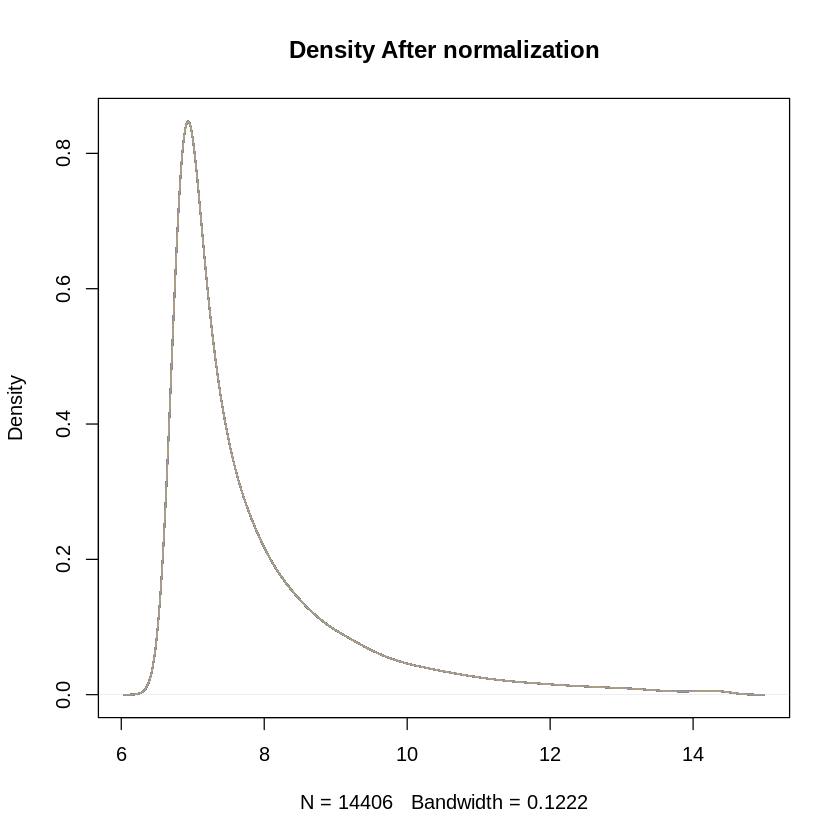

In [ ]:
plot(density(expr_log[,1]),
     col=1,
     main="Density before normalization")

for(i in 2:ncol(expr_log)){
  lines(density(expr_log[,i]), col=i)
}

plot(density(expr_norm[,1]),
     col=1,
     main="Density After normalization")

for(i in 2:ncol(expr_norm)){
  lines(density(expr_norm[,i]), col=i)
}

Remove zero variance

In [ ]:
varRow =apply(expr_norm, 1, var)

expr_norm = expr_norm[varRow > 0 & !is.na(varRow), ]

Remove Lowest 10% Variance

In [ ]:
varRow= apply(expr_norm, 1, var)
threshold = quantile(varRow, 0.10)

expr_final = expr_norm[varRow > threshold, ]

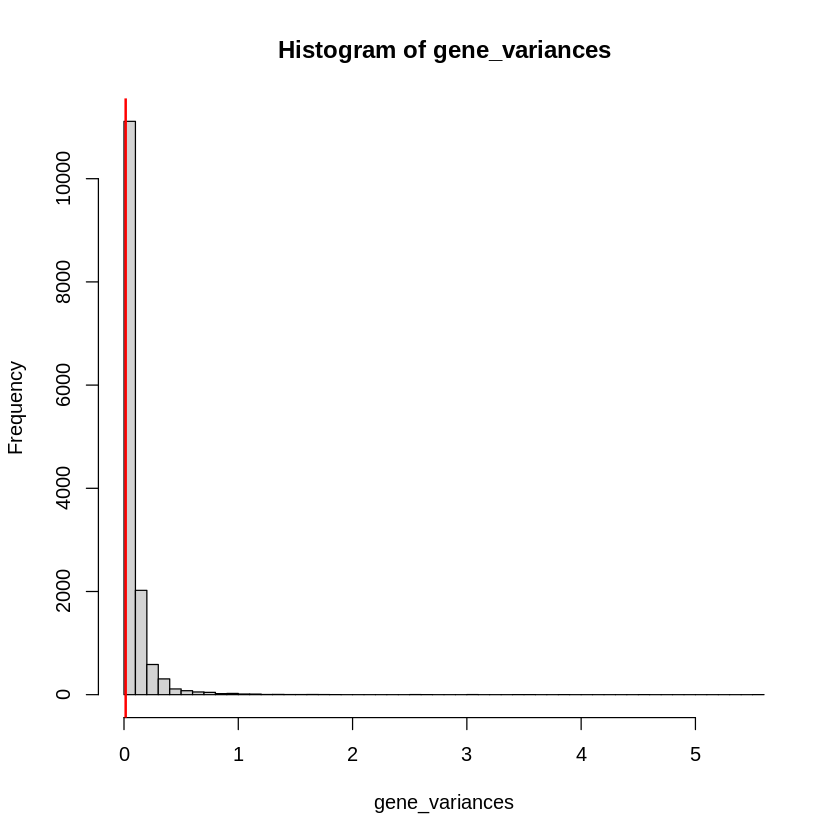

In [ ]:
gene_variances = apply(expr_norm, 1, var)
hist(gene_variances, breaks=50)
abline(v=threshold, col="red", lwd=2)

In [ ]:
head(expr_final,n=5)

,ALS03718.AVG_Signal,ALS03729.AVG_Signal,ALS05873.AVG_Signal,ALS07130.AVG_Signal,ALS04157.AVG_Signal,ALS03901.AVG_Signal,ALS05882.AVG_Signal,ALS04332.AVG_Signal,ALS04139.AVG_Signal,ALS05942.AVG_Signal,⋯,ALS06060.AVG_Signal,ALS06168.AVG_Signal,ALS04910.AVG_Signal,ALS06170.AVG_Signal,ALS06166.AVG_Signal,ALS04978.AVG_Signal,ALS05161.AVG_Signal,ALS06059.AVG_Signal,ALS04688.AVG_Signal,ALS06998.AVG_Signal
ILMN_1698554,6.877591,6.879940,6.887897,7.136447,6.817990,6.834716,6.857615,6.843998,6.787264,7.027357,⋯,6.661819,6.935872,6.699331,6.587563,6.578368,6.659948,6.699756,6.772864,6.806046,6.639234
ILMN_2061446,7.392046,7.441304,7.752903,7.857091,7.565276,7.456435,7.628340,7.264275,7.358067,7.674274,⋯,7.621281,7.707803,7.602646,7.732648,7.631604,7.788517,7.688230,7.657245,7.568730,7.538879
ILMN_3237396,7.057595,7.131018,7.087485,7.065490,7.056428,7.186755,7.068267,7.270352,7.252696,7.083853,⋯,7.121729,7.236714,7.000353,7.230878,7.176785,7.122753,7.139493,7.311346,7.249473,7.168474
ILMN_1688755,7.980540,7.928039,7.759445,8.635366,7.914430,7.876602,8.027885,7.634699,8.160380,8.088260,⋯,8.564514,8.372126,8.782514,7.924492,8.425319,8.557154,8.300528,8.588857,8.494232,8.305271
ILMN_1653165,7.213639,7.458387,7.248579,7.505185,7.489064,7.384841,7.528285,7.183217,7.315954,7.407578,⋯,7.540812,7.467442,7.290092,7.305492,7.453572,7.658179,7.319745,7.606688,7.499525,7.470329


MetaData Analysis

In [ ]:
# Read and Process Metadata


meta_path = "/content/drive/MyDrive/Colab Notebooks/davrproject/GSE112680_series_matrix.txt"
lines = readLines(meta_path)

sample_start = grep("^!Sample_geo_accession", lines)
sample_end   = grep("^!series_matrix_table_begin", lines) - 1

sample_lines = lines[sample_start:sample_end]
sample_lines = gsub("!Sample_", "", sample_lines)

metadata = read.delim(text=sample_lines, header=TRUE, stringsAsFactors=FALSE)

meta_fields = metadata[,1]
meta_matrix = metadata[,-1]

meta_t = as.data.frame(t(meta_matrix), stringsAsFactors=FALSE)
colnames(meta_t) = meta_fields
meta_t$geo_accession = rownames(meta_t)
rownames(meta_t) = NULL

In [ ]:
metadata

geo_accession,GSM3079737,GSM3079740,GSM3079742,GSM3079744,GSM3079746,GSM3079749,GSM3079751,GSM3079753,GSM3079756,⋯,GSM3080171,GSM3080172,GSM3080173,GSM3080174,GSM3080175,GSM3080176,GSM3080177,GSM3080178,GSM3080179,GSM3080180
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
status,Public on Apr 05 2018,Public on Apr 05 2018,Public on Apr 05 2018,Public on Apr 05 2018,Public on Apr 05 2018,Public on Apr 05 2018,Public on Apr 05 2018,Public on Apr 05 2018,Public on Apr 05 2018,⋯,Public on Apr 05 2018,Public on Apr 05 2018,Public on Apr 05 2018,Public on Apr 05 2018,Public on Apr 05 2018,Public on Apr 05 2018,Public on Apr 05 2018,Public on Apr 05 2018,Public on Apr 05 2018,Public on Apr 05 2018
submission_date,Apr 04 2018,Apr 04 2018,Apr 04 2018,Apr 04 2018,Apr 04 2018,Apr 04 2018,Apr 04 2018,Apr 04 2018,Apr 04 2018,⋯,Apr 04 2018,Apr 04 2018,Apr 04 2018,Apr 04 2018,Apr 04 2018,Apr 04 2018,Apr 04 2018,Apr 04 2018,Apr 04 2018,Apr 04 2018
last_update_date,Apr 05 2018,Apr 05 2018,Apr 05 2018,Apr 05 2018,Apr 05 2018,Apr 05 2018,Apr 05 2018,Apr 05 2018,Apr 05 2018,⋯,Apr 05 2018,Apr 05 2018,Apr 05 2018,Apr 05 2018,Apr 05 2018,Apr 05 2018,Apr 05 2018,Apr 05 2018,Apr 05 2018,Apr 05 2018
type,RNA,RNA,RNA,RNA,RNA,RNA,RNA,RNA,RNA,⋯,RNA,RNA,RNA,RNA,RNA,RNA,RNA,RNA,RNA,RNA
channel_count,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,1
source_name_ch1,whole blood_MIM,whole blood_ALS,whole blood_ALS,whole blood_CON,whole blood_MIM,whole blood_ALS,whole blood_ALS,whole blood_MIM,whole blood_ALS,⋯,whole blood_CON,whole blood_CON,whole blood_CON,whole blood_CON,whole blood_CON,whole blood_CON,whole blood_CON,whole blood_CON,whole blood_CON,whole blood_ALS
organism_ch1,Homo sapiens,Homo sapiens,Homo sapiens,Homo sapiens,Homo sapiens,Homo sapiens,Homo sapiens,Homo sapiens,Homo sapiens,⋯,Homo sapiens,Homo sapiens,Homo sapiens,Homo sapiens,Homo sapiens,Homo sapiens,Homo sapiens,Homo sapiens,Homo sapiens,Homo sapiens
characteristics_ch1,Sex: m,Sex: m,Sex: v,Sex: v,Sex: m,Sex: m,Sex: m,Sex: m,Sex: m,⋯,Sex: m,Sex: m,Sex: v,Sex: m,Sex: v,Sex: m,Sex: v,Sex: m,Sex: m,Sex: m
characteristics_ch1,diagnosis: MIM,diagnosis: ALS,diagnosis: ALS,diagnosis: CON,diagnosis: MIM,diagnosis: ALS,diagnosis: ALS,diagnosis: MIM,diagnosis: ALS,⋯,diagnosis: CON,diagnosis: CON,diagnosis: CON,diagnosis: CON,diagnosis: CON,diagnosis: CON,diagnosis: CON,diagnosis: CON,diagnosis: CON,diagnosis: ALS


In [ ]:
meta_t

status,submission_date,last_update_date,type,channel_count,source_name_ch1,organism_ch1,characteristics_ch1,characteristics_ch1.1,characteristics_ch1.2,⋯,contact_department,contact_institute,contact_address,contact_city,contact_state,contact_zip/postal_code,contact_country,supplementary_file,data_row_count,geo_accession
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Public on Apr 05 2018,Apr 04 2018,Apr 05 2018,RNA,1,whole blood_MIM,Homo sapiens,Sex: m,diagnosis: MIM,site_onset: NA,⋯,"Neurology, Brain Center Rudolf Magnus",University Medical Center Utrecht,"Heidelberglaan 100, F.02.230",Utrecht,Utrecht,3584 CX,Netherlands,NONE,29830,GSM3079737
Public on Apr 05 2018,Apr 04 2018,Apr 05 2018,RNA,1,whole blood_ALS,Homo sapiens,Sex: m,diagnosis: ALS,site_onset: s,⋯,"Neurology, Brain Center Rudolf Magnus",University Medical Center Utrecht,"Heidelberglaan 100, F.02.230",Utrecht,Utrecht,3584 CX,Netherlands,NONE,29830,GSM3079740
Public on Apr 05 2018,Apr 04 2018,Apr 05 2018,RNA,1,whole blood_ALS,Homo sapiens,Sex: v,diagnosis: ALS,site_onset: s,⋯,"Neurology, Brain Center Rudolf Magnus",University Medical Center Utrecht,"Heidelberglaan 100, F.02.230",Utrecht,Utrecht,3584 CX,Netherlands,NONE,29830,GSM3079742
Public on Apr 05 2018,Apr 04 2018,Apr 05 2018,RNA,1,whole blood_CON,Homo sapiens,Sex: v,diagnosis: CON,site_onset: NA,⋯,"Neurology, Brain Center Rudolf Magnus",University Medical Center Utrecht,"Heidelberglaan 100, F.02.230",Utrecht,Utrecht,3584 CX,Netherlands,NONE,29830,GSM3079744
Public on Apr 05 2018,Apr 04 2018,Apr 05 2018,RNA,1,whole blood_MIM,Homo sapiens,Sex: m,diagnosis: MIM,site_onset: NA,⋯,"Neurology, Brain Center Rudolf Magnus",University Medical Center Utrecht,"Heidelberglaan 100, F.02.230",Utrecht,Utrecht,3584 CX,Netherlands,NONE,29830,GSM3079746
Public on Apr 05 2018,Apr 04 2018,Apr 05 2018,RNA,1,whole blood_ALS,Homo sapiens,Sex: m,diagnosis: ALS,site_onset: s,⋯,"Neurology, Brain Center Rudolf Magnus",University Medical Center Utrecht,"Heidelberglaan 100, F.02.230",Utrecht,Utrecht,3584 CX,Netherlands,NONE,29830,GSM3079749
Public on Apr 05 2018,Apr 04 2018,Apr 05 2018,RNA,1,whole blood_ALS,Homo sapiens,Sex: m,diagnosis: ALS,site_onset: s,⋯,"Neurology, Brain Center Rudolf Magnus",University Medical Center Utrecht,"Heidelberglaan 100, F.02.230",Utrecht,Utrecht,3584 CX,Netherlands,NONE,29830,GSM3079751
Public on Apr 05 2018,Apr 04 2018,Apr 05 2018,RNA,1,whole blood_MIM,Homo sapiens,Sex: m,diagnosis: MIM,site_onset: NA,⋯,"Neurology, Brain Center Rudolf Magnus",University Medical Center Utrecht,"Heidelberglaan 100, F.02.230",Utrecht,Utrecht,3584 CX,Netherlands,NONE,29830,GSM3079753
Public on Apr 05 2018,Apr 04 2018,Apr 05 2018,RNA,1,whole blood_ALS,Homo sapiens,Sex: m,diagnosis: ALS,site_onset: s,⋯,"Neurology, Brain Center Rudolf Magnus",University Medical Center Utrecht,"Heidelberglaan 100, F.02.230",Utrecht,Utrecht,3584 CX,Netherlands,NONE,29830,GSM3079756


In [ ]:
Alignment of dataframe with metadata

In [ ]:
# GROUP ALIGNMENT (ORDER-BASED)

cat("Expression samples:", ncol(expr_norm), "\n")
cat("Metadata samples:", nrow(meta_t), "\n")

# These MUST both be 376, if yes then order is aligned

# Extract full group vector
group_full = meta_t$source_name_ch1

cat("\nFull group distribution:\n")
print(table(group_full))

# Remove MIM
keep = group_full %in% c("whole blood_ALS","whole blood_CON")

expr_final = expr_norm[, keep]
group = factor(group_full[keep])

cat("\nAfter removing MIM:\n")
print(table(group))

cat("\nCheck alignment:\n")
print(length(group) == ncol(expr_final))

Expression samples: 376 
Metadata samples: 376 

Full group distribution:
group_full
whole blood_ALS whole blood_CON whole blood_MIM 
            164             137              75 

After removing MIM:
group
whole blood_ALS whole blood_CON 
            164             137 

Check alignment:
[1] TRUE


Saving expression matrix and group vectors for the transcriptome pipeline function

In [ ]:
# Save expression matrix
write.csv(expr_final, "expr_matrix.csv", row.names = TRUE)

# Create and save metadata for the pipeline
metadata_for_pipeline = data.frame(
  Sample = colnames(expr_final),
  Group = group
)

write.csv(metadata_for_pipeline, "metadata_for_pipeline.csv", row.names = FALSE)

Transcriptome pipeline function

In [ ]:
run_universal_pipeline = function(
  expr_file,         # QCed expression matrix CSV (genes × samples)
  metadata_file,     # Metadata CSV
  group_column,      # Name of the column in metadata to use as group
  group1,            # Case/experimental group label
  group2,            # Control group label
  adjP_cutoff = 0.05,
  logFC_cutoff = 1,
  top_n_heatmap = 50,
  output_prefix = "Analysis"
){

## 1.Load libraries

  library(limma)
  library(ggplot2)
  library(clusterProfiler)
  library(org.Hs.eg.db)
  library(AnnotationDbi)
  # Install and load illuminaHumanv4.db for probe ID mapping
  if(!requireNamespace("illuminaHumanv4.db", quietly=TRUE)){
    BiocManager::install("illuminaHumanv4.db")
  }
  library(illuminaHumanv4.db)

  # For ComplexHeatmap
  if(!requireNamespace("ComplexHeatmap", quietly=TRUE)){
    BiocManager::install("ComplexHeatmap")
  }
  library(ComplexHeatmap)
  library(circlize)

 ## 2.Load data
expr_matrix = read.csv(expr_file, row.names = 1, check.names = FALSE)
metadata = read.csv(metadata_file, row.names = 1, check.names = FALSE)



## 3.  Align samples

common_samples = intersect(colnames(expr_matrix), rownames(metadata))

expr_matrix = expr_matrix[, common_samples]
metadata = metadata[common_samples, , drop = FALSE]

group_vector = factor(metadata[[group_column]])

# Fix names for limma
levels(group_vector) = make.names(levels(group_vector))

cat("Samples used:", length(common_samples), "\n")
cat("Groups:", levels(group_vector), "\n")

## 4. Differential Expression (limma)

  design = model.matrix(~0 + group_vector)
  colnames(design) = levels(group_vector)
  fit = lmFit(expr_matrix, design)
  contrast_matrix = makeContrasts(
   contrasts = paste0(make.names(group1), "-", make.names(group2)),
   levels = design
  )
  fit2 = contrasts.fit(fit, contrast_matrix)
  fit2 = eBayes(fit2)

  deg_results = topTable(fit2, number = Inf, adjust.method = "BH")
  DEGs = deg_results[
    deg_results$adj.P.Val < adjP_cutoff &
    abs(deg_results$logFC) > logFC_cutoff, ]

  # Save DE results
  write.csv(deg_results, paste0(output_prefix,"_ALL_genes.csv"))
  write.csv(DEGs, paste0(output_prefix,"_Significant_DEGs.csv"))
  write.csv(head(deg_results,100), paste0(output_prefix,"_Top100_DEGs.csv"))

  ################################################
  # PCA
  ################################################
  expr_scaled = t(scale(t(expr_matrix)))
  pca_res = prcomp(t(expr_scaled))
  pca_df = data.frame(PC1 = pca_res$x[,1],
                       PC2 = pca_res$x[,2],
                       Group = group_vector)
  pca_plot = ggplot(pca_df, aes(PC1, PC2, color = Group)) +
    geom_point(size=3) +
    labs(
      title = "PCA Plot",
      x = paste0("PC1 (", round(summary(pca_res)$importance[2,1]*100,2), "%)"),
      y = paste0("PC2 (", round(summary(pca_res)$importance[2,2]*100,2), "%)")
    ) +
    theme_minimal()
  print(pca_plot)
  ggsave(paste0(output_prefix,"_PCA.png"), pca_plot, width=7, height=5)

################################################
# Volcano plot
################################################

volcano_df = deg_results
volcano_df$Significant = volcano_df$adj.P.Val < adjP_cutoff & abs(volcano_df$logFC) > logFC_cutoff

volcano_plot = ggplot(volcano_df, aes(logFC, -log10(adj.P.Val), color = Significant)) +
  geom_point(alpha = 0.6) +
  theme_minimal() +
  labs(title = "Volcano Plot")

print(volcano_plot)

ggsave(
  paste0(output_prefix,"_Volcano.png"),
  plot = volcano_plot,
  width = 7,
  height = 5
)

################################################
# Heatmap of top DEGs (ComplexHeatmap)
################################################

if (nrow(DEGs) > 0) {

  top_deg_genes = rownames(DEGs)[1:min(top_n_heatmap, nrow(DEGs))]
  top_deg_genes = intersect(top_deg_genes, rownames(expr_scaled))

  if (length(top_deg_genes) > 0) {

    heatmap_matrix = expr_scaled[top_deg_genes, , drop = FALSE]

    annotation_df = data.frame(Group = group_vector)
    rownames(annotation_df) = colnames(expr_matrix)

    group_levels = levels(group_vector)

    col_annotation = list(
      Group = c(
        "whole.blood_ALS" = "#E64B35",
        "whole.blood_CON" = "#4DBBD5"
      )
    )

    ha = HeatmapAnnotation(
      Group = annotation_df$Group,
      col = col_annotation
    )

    ht_obj = ComplexHeatmap::Heatmap(
      heatmap_matrix,
      name = "Expression",
      cluster_rows = TRUE,
      cluster_columns = TRUE,
      show_row_names = TRUE,
      show_column_names = FALSE,
      row_names_gp = grid::gpar(fontsize = 8),
      column_split = annotation_df$Group,
      top_annotation = ha
    )

    draw(ht_obj)

  }
}
 ################################################
# Probe ID -> Gene Symbol -> Entrez ID
################################################

probe_ids = rownames(DEGs)

gene_symbols = na.omit(mapIds(
  illuminaHumanv4.db,
  keys = probe_ids,
  column = "SYMBOL",
  keytype = "PROBEID",
  multiVals = "first"
))

entrez_ids = na.omit(mapIds(
  org.Hs.eg.db,
  keys = gene_symbols,
  column = "ENTREZID",
  keytype = "SYMBOL",
  multiVals = "first"
))

 ################################################
# GO enrichment
################################################

go_results = NULL

if(length(entrez_ids) > 10){

go_results = enrichGO(
  gene = entrez_ids,
  OrgDb = org.Hs.eg.db,
  ont = "BP",
  pAdjustMethod = "BH",
  readable = TRUE
)

write.csv(as.data.frame(go_results),
          paste0(output_prefix,"_GO_BP.csv"))

go_plot = dotplot(go_results, showCategory=15)

print(go_plot)

ggsave(paste0(output_prefix,"_GO_dotplot.png"),
       go_plot,
       width=7,
       height=5)

}
 else {

cat("Not enough genes for GO enrichment\n")

}

  ################################################
  # KEGG enrichment
  ################################################
  kegg_results = if(length(entrez_ids) > 0){
    enrichKEGG(gene = entrez_ids, organism="hsa", pAdjustMethod="BH")
  } else { NULL }

  if(!is.null(kegg_results)){
    write.csv(as.data.frame(kegg_results), paste0(output_prefix,"_KEGG.csv"))
    kegg_plot = dotplot(kegg_results, showCategory=15) + ggtitle("KEGG Pathway Enrichment")
    print(kegg_plot)
    ggsave(paste0(output_prefix,"_KEGG_dotplot.png"), kegg_plot, width=7, height=5)
  }

  ################################################
  # Summary
  ################################################
  summary_list = list(
    Total_genes = nrow(deg_results),
    Significant_DEGs = nrow(DEGs),
    Upregulated = sum(DEGs$logFC > 0),
    Downregulated = sum(DEGs$logFC < 0),
    Top_GO = if(!is.null(go_results)) go_results@result$Description[1] else NA,
    Top_KEGG = if(!is.null(kegg_results)) kegg_results@result$Description[1] else NA
  )

  cat("Pipeline Summary:\n")
  print(summary_list)

  ################################################
  # Return
  ################################################
  return(list(
    DEGs = DEGs,
    All_genes = deg_results,
    PCA = pca_res,
    GO = go_results,
    KEGG = kegg_results,
    Summary = summary_list
  ))
}

Calling the function

Samples used: 301 
Groups: whole.blood_ALS whole.blood_CON 


'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns



Pipeline Summary:
$Total_genes
[1] 14406

$Significant_DEGs
[1] 16

$Upregulated
[1] 9

$Downregulated
[1] 7

$Top_GO
[1] "cytoplasmic translation"

$Top_KEGG
[1] "Ribosome"



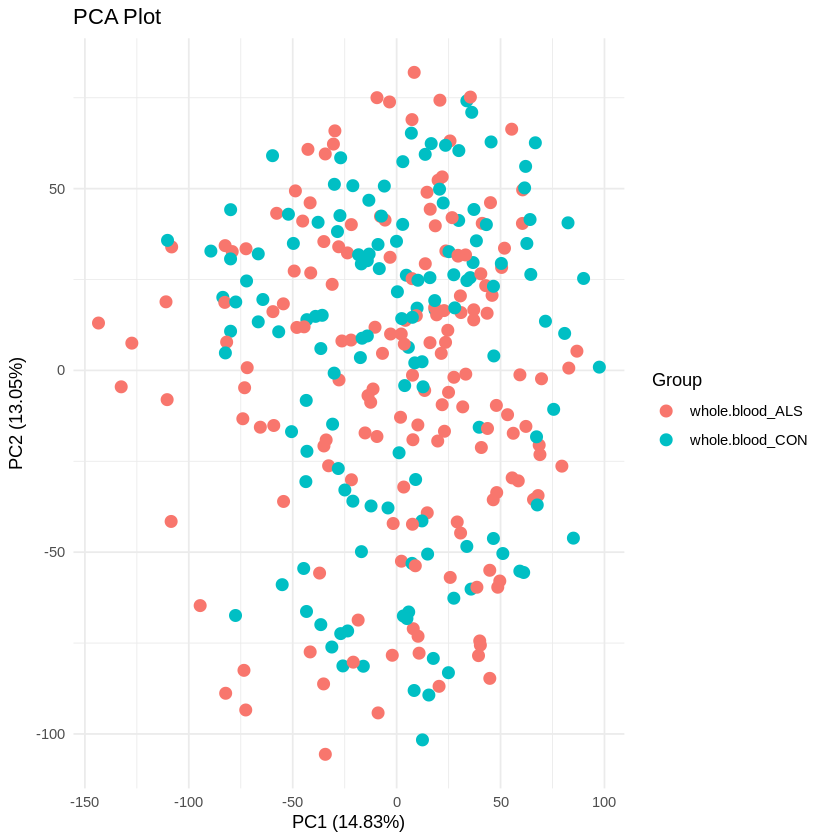

In [ ]:
pipeline_output = run_universal_pipeline(
  expr_file = "expr_matrix.csv",
  metadata_file = "metadata_for_pipeline.csv",
  group_column = "Group", # Changed from "source_name_ch1" to "Group"
  group1 = "whole blood_ALS",
  group2 = "whole blood_CON",
  adjP_cutoff = 0.05,
  logFC_cutoff = 0.5,
  output_prefix = "ALS_analysis"
)

Access outputs individually

In [ ]:
pipeline_output$DEGs       # Significant DEGs


,logFC,AveExpr,t,P.Value,adj.P.Val,B
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ILMN_1733559,-1.3022299,11.043576,-7.993708,2.802987e-14,1.755645e-11,21.892963
ILMN_2255310,0.5065566,8.406522,7.825918,8.559204e-14,3.421114e-11,20.815060
ILMN_3246805,-1.1740832,10.023991,-7.821948,8.786701e-14,3.421114e-11,20.789737
ILMN_3249578,-1.1119598,11.567426,-7.383093,1.514035e-12,3.959060e-10,18.043535
ILMN_1703337,-1.2192218,7.566023,-7.380524,1.538993e-12,3.959060e-10,18.027773
ILMN_1787949,0.6358996,10.865876,7.289756,2.735477e-12,6.062658e-10,17.473412
ILMN_3243593,-0.7909632,7.514849,-7.197672,4.879166e-12,9.169923e-10,16.915880
ILMN_3246850,0.6264445,11.038635,7.173780,5.665001e-12,1.046282e-09,16.772035
ILMN_1656807,0.5049304,10.670220,7.142947,6.865611e-12,1.221062e-09,16.586900


In [ ]:
pipeline_output$All_genes  # All genes


,logFC,AveExpr,t,P.Value,adj.P.Val,B
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ILMN_1753608,-0.2644265,8.879244,-11.015894,6.017022e-24,8.668122e-20,43.44453
ILMN_3258356,0.1929898,7.177763,10.336488,1.217526e-21,8.769840e-18,38.29908
ILMN_1814812,0.3198700,7.428538,10.063066,9.878879e-21,4.743837e-17,36.27071
ILMN_1732705,-0.3322752,8.582027,-9.917258,2.984067e-20,1.074712e-16,35.19980
ILMN_2124386,0.2401122,7.968513,9.433241,1.104839e-18,3.183262e-15,31.70201
ILMN_2075334,0.4978551,11.384641,9.202270,5.988805e-18,1.437912e-14,30.06566
ILMN_1706057,-0.2422023,9.709128,-9.176239,7.235299e-18,1.489025e-14,29.88263
ILMN_1783226,0.2449081,9.115559,8.773728,1.296582e-16,2.122395e-13,27.08990
ILMN_3207020,0.2950432,12.155779,8.770564,1.325944e-16,2.122395e-13,27.06824


In [ ]:
pipeline_output$GO         # GO enrichment


#
# over-representation test
#
#...@organism 	 Homo sapiens 
#...@ontology 	 BP 
#...@keytype 	 ENTREZID 
#...@gene 	 chr [1:6] "100008589" "6210" "100008588" "6155" "6133" "6189"
#...pvalues adjusted by 'BH' with cutoff <0.05 
#...4 enriched terms found
'data.frame':	4 obs. of  12 variables:
 $ ID            : chr  "GO:0002181" "GO:0042254" "GO:0022613" "GO:0042274"
 $ Description   : chr  "cytoplasmic translation" "ribosome biogenesis" "ribonucleoprotein complex biogenesis" "ribosomal small subunit biogenesis"
 $ GeneRatio     : chr  "4/4" "3/4" "3/4" "2/4"
 $ BgRatio       : chr  "208/18860" "318/18860" "496/18860" "107/18860"
 $ RichFactor    : num  0.01923 0.00943 0.00605 0.01869
 $ FoldEnrichment: num  90.7 44.5 28.5 88.1
 $ zScore        : num  18.94 11.39 9.05 13.16
 $ pvalue        : num  1.44e-08 1.88e-05 7.09e-05 1.90e-04
 $ p.adjust      : num  1.29e-07 8.44e-05 2.13e-04 4.27e-04
 $ qvalue        : num  4.54e-08 2.96e-05 7.46e-05 1.50e-04
 $ geneID        : chr  "RPS15A/RPL

In [ ]:
pipeline_output$KEGG       # KEGG enrichment


#
# over-representation test
#
#...@organism 	 hsa 
#...@ontology 	 KEGG 
#...@keytype 	 kegg 
#...@gene 	 chr [1:6] "100008589" "6210" "100008588" "6155" "6133" "6189"
#...pvalues adjusted by 'BH' with cutoff <0.05 
#...3 enriched terms found
'data.frame':	3 obs. of  14 variables:
 $ category      : chr  "Genetic Information Processing" "Human Diseases" "Genetic Information Processing"
 $ subcategory   : chr  "Translation" "Infectious disease: viral" "Translation"
 $ ID            : chr  "hsa03010" "hsa05171" "hsa03008"
 $ Description   : chr  "Ribosome" "Coronavirus disease - COVID-19" "Ribosome biogenesis in eukaryotes"
 $ GeneRatio     : chr  "6/6" "4/6" "2/6"
 $ BgRatio       : chr  "222/9370" "238/9370" "183/9370"
 $ RichFactor    : num  0.027 0.0168 0.0109
 $ FoldEnrichment: num  42.2 26.2 17.1
 $ zScore        : num  15.73 9.99 5.56
 $ pvalue        : num  1.65e-10 5.85e-06 5.40e-03
 $ p.adjust      : num  4.96e-10 8.78e-06 5.40e-03
 $ qvalue        : logi  NA NA NA
 $ geneID  

In [ ]:
pipeline_output$Summary    # Pipeline summary

$Total_genes
[1] 14406

$Significant_DEGs
[1] 16

$Upregulated
[1] 9

$Downregulated
[1] 7

$Top_GO
[1] "cytoplasmic translation"

$Top_KEGG
[1] "Ribosome"

Displaying any PNG images in colab function

In [ ]:
display_all_pipeline_images = function(output_prefix = "ALS_analysis") {
  # Install and load required packages if not already present
  if(!requireNamespace("gridExtra", quietly = TRUE)){
    install.packages("gridExtra")
  }
  if(!requireNamespace("png", quietly = TRUE)){
    install.packages("png")
  }
  if(!requireNamespace("grid", quietly = TRUE)){
    install.packages("grid")
  }
  library(gridExtra)
  library(png)
  library(grid)

  # Get all PNG files related to the output_prefix
  # We look for files starting with the prefix and ending with .png
  all_png_files = list.files(pattern=paste0("^", output_prefix, ".*\\.png$"), full.names = TRUE)

  # Filter out files that are empty or might be problematic
  valid_png_files = c()
  for (file in all_png_files) {
    if (file.exists(file) && file.info(file)$size > 0) {
      valid_png_files = c(valid_png_files, file)
    } else {
      cat(paste0("Skipping file '", file, "': it is empty or does not exist.\n"))
    }
  }

  if (length(valid_png_files) == 0) {
    cat("No valid PNG files found to display for prefix: ", output_prefix, "\n")
    return(invisible(NULL))
  }

  # Read PNGs and convert to raster grobs
  grobs_list = lapply(valid_png_files, function(file) {
    img = readPNG(file)
    rasterGrob(img, interpolate = TRUE)
  })

  # Determine appropriate grid layout (e.g., 2 rows, 3 columns)
  num_images = length(grobs_list)
  if (num_images == 0) {
    return(invisible(NULL))
  } else if (num_images <= 3) {
    num_cols = num_images
    num_rows = 1
  } else {
    num_cols = 3
    num_rows = ceiling(num_images / num_cols)
  }

  # Arrange and display all grobs in a dynamic layout
  cat("Displaying ", num_images, " images...\n")
  grid.arrange(grobs = grobs_list, ncol = num_cols, nrow = num_rows)

  return(invisible(NULL))
}


Calling Display Function

Skipping file './ALS_analysis_Heatmap.png': it is empty or does not exist.
Displaying  5  images...


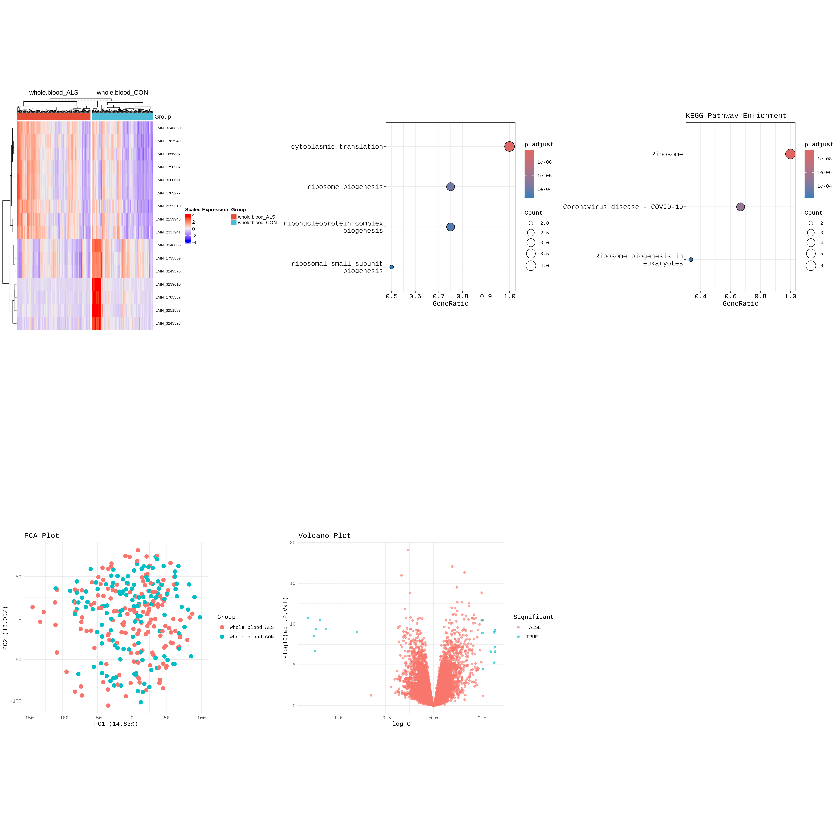

In [ ]:
# Example of how to call the function for your analysis
display_all_pipeline_images(output_prefix = "ALS_analysis")